# Continuación del curso de Matemáticas Aplicadas III

**Agenda**
- **Continuación del curso.**
- **Integración múltiple** Capítulo 5 del libro de Marsden & Tromba (2011)
---

## Ideas fundamentales del cálculo

Los dos problemas fundamentales en cálculo se pueden reducir a:  **derivar** y **evaluar integrales definidas**. Más allá de la diferenciación y la integración, una de las principales aplicaciones del cálculo diferencial es la optimización en una o varias variables.

Inicialmente nos interesa el problema de la integral, la
expresión matemática  para encontrar la cantidad total en una región
del plano o del espacio. Por ejemplo área, volumen,  masa total de un cuerpo,
 carga eléctrica total en una región, o  población total de un país.

## Integrales Dobles

Para el caso de funciones de varias variables ya no pensamos en el área bajo una curva sino en el volumen. Vamos a iniciar nuestro estudio de integrales dobles, o de funciones de dos variables, estudiando el problema del calculo del volumen de una región sobre el plano, es decir, responderemos la pregunta ¿Cómo podemos encontrar volumen total sobre una región plana $R$ bajo una función $f=f(x,y)$?. Empecemos tratando de usar el concepto de suma de Riemann en una variable y generalizarlo para calcular el area de la región mas sencilla del plano:

$$R=\{(x,y): a\leq x \leq b, c\leq y \leq d\}$$





Mounted at /content/drive
Tomado de Marsden & Tromba (2011)


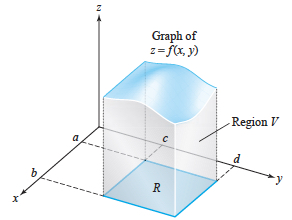

In [ ]:
from google.colab import files
from google.colab import drive

from IPython.display import Image

#drive.mount('/content/drive')
print('Tomado de Marsden & Tromba (2011)')
Image(filename='/content/drive/MyDrive/Figures/dd.jpg')


En matemáticas, una **integral de línea** (a veces llamada integral de camino o integral de contorno) es una integral donde la función a integrar se evalúa a lo largo de una curva. En contraste con las integrales múltiples que se evalúan sobre regiones o volúmenes, una integral de línea se define a lo largo de un camino unidimensional en un espacio multidimensional. Se utiliza comúnmente en física para calcular el trabajo realizado por una fuerza a lo largo de un camino, el flujo de un campo vectorial a través de una curva, o la masa de un alambre de densidad variable. La forma general de una integral de línea de una función escalar $f(x, y, z)$ a lo largo de una curva $C$ parametrizada por $\mathbf{r}(t) = (x(t), y(t), z(t))$ para $a \le t \le b$ es:

$$\int_C f(x, y, z)\,ds = \int_a^b f(\mathbf{r}(t)) \|\mathbf{r}'(t)\|\,dt$$

Donde $ds$ representa un elemento de longitud de arco infinitesimal, y $\|\mathbf{r}'(t)\|$ es la magnitud del vector tangente a la curva.

Para resolver una integral de línea en Python de forma simbólica, podemos usar la biblioteca `sympy`. Necesitamos definir:

1.  La función $f(x, y, z)$ a integrar.
2.  La curva $C$ parametrizada como $\mathbf{r}(t) = (x(t), y(t), z(t))$.
3.  Calcular la magnitud del vector tangente de la curva, $\|\mathbf{r}'(t)\|$.
4.  Sustituir la curva parametrizada en la función y multiplicar por la magnitud del vector tangente.
5.  Realizar la integración definida con respecto a $t$ en el rango dado.

Aquí hay un ejemplo donde integramos la función $f(x, y) = x^2 + y^2$ a lo largo de la curva $C$ dada por $\mathbf{r}(t) = (\cos t, \sin t)$ para $0 \le t \le \pi$.

In [ ]:
import sympy

# 1. Definir las variables simbólicas
x, y, z, t = sympy.symbols('x y z t')

# 2. Definir la función a integrar f(x, y, z)
# En este ejemplo, f(x, y) = x**2 + y**2
f = x**2 + y**2
print(f"Función a integrar: f(x, y) = {f}")

# 3. Definir la curva parametrizada r(t)
# En este ejemplo, r(t) = (cos(t), sin(t)) para una curva en 2D
r_t = sympy.Matrix([sympy.cos(t), sympy.sin(t)])
print(f"\nCurva parametrizada: r(t) = {r_t}")

# 4. Calcular el vector tangente r'(t)
r_prime_t = sympy.diff(r_t, t)
print(f"Vector tangente: r'(t) = {r_prime_t}")

# 5. Calcular la magnitud del vector tangente ||r'(t)||
# Esto es la norma euclidiana del vector tangente
magnitude_r_prime_t = sympy.sqrt(sympy.simplify(r_prime_t.dot(r_prime_t)))
print(f"Magnitud del vector tangente: ||r'(t)|| = {magnitude_r_prime_t}")

# 6. Sustituir la curva en la función f y multiplicar por ||r'(t)||
# Primero, creamos un diccionario para las sustituciones
# Asegurémonos de que el número de componentes de r_t coincide con las variables en f
if f.free_symbols.issubset({x, y, z}):
    # Si f depende de x, y
    if len(r_t) == 2:
        f_at_r_t = f.subs({x: r_t[0], y: r_t[1]})
    # Si f depende de x, y, z
    elif len(r_t) == 3:
        f_at_r_t = f.subs({x: r_t[0], y: r_t[1], z: r_t[2]})
    else:
        raise ValueError("La dimensión de la curva no coincide con las variables de la función")
else:
    raise ValueError("Las variables de la función no están en el conjunto {x, y, z}")

integrand = f_at_r_t * magnitude_r_prime_t
print(f"\nIntegrando (f(r(t)) * ||r'(t)||): {integrand}")

# 7. Definir los límites de integración para t
a = 0
b = sympy.pi

# 8. Realizar la integración definida
line_integral_result = sympy.integrate(integrand, (t, a, b))
print(f"\nEl resultado de la integral de línea es: {line_integral_result}")


Función a integrar: f(x, y) = x**2 + y**2

Curva parametrizada: r(t) = Matrix([[cos(t)], [sin(t)]])
Vector tangente: r'(t) = Matrix([[-sin(t)], [cos(t)]])
Magnitud del vector tangente: ||r'(t)|| = 1

Integrando (f(r(t)) * ||r'(t)||): sin(t)**2 + cos(t)**2

El resultado de la integral de línea es: pi


Antes de dar una definición rigurosa intentaremos explorar una idea geométrica sobre el volumen bajo la gráfica de una función $f=f(x,y)\geq 0$. Recordemos que, en general, las fórmulas de aproximación para integrales y por ende para el cálculo de áreas bajo la curva $y=f(x),x\in[a,b]$ vienen determinadas por la escogencia de puntos de prueba $x^*\in[a,b]$. En general son de la forma $$ A_{approx}=h\sum_{i=0}^n f(x^*), $$

donde $h=\Delta x$ es la base de los rectangulos y $f(x_i^*)$ determina la altura.


Ahora bien, en este caso a diferencia del que nos interesa ahora, se subdividia el intervalo $[a,b]$ en $n$ subintervalos de longitud $h$. Si ahora queremos es calcular el área no bajo una curva sino de una región rectangular, ¿cómo adaptariamos la idea anterior para hallarla? ¿cómo sería una forma sencilla de subdividir un rectángulo?




Si consideramos una función $f(x,y)=k,\,k\in \mathbb{R}$, cuál sería el volúmen sobre el rectángulo $R$?

En notación de integrales dobles tendríamos

$$\int\int_R f(x,y)\, dA= \int_c^d\int_a^b f(x,y)\, dx dy= k \cdot (b-a) \cdot (d-c)$$

#Principio de Cavalieri

Consideremos un cuerpo sólido y sea $ A(x)$  su área de sección transversal en un plano $Px$ medido a una distancia x de un plano de referencia

Tomado de Marsden & Tromba  (2011)


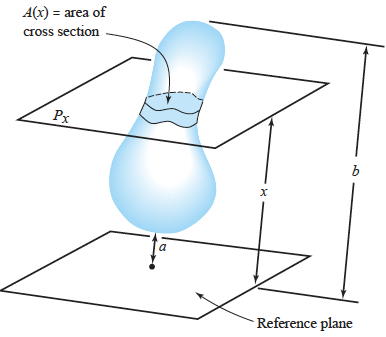

In [ ]:
print('Tomado de Marsden & Tromba  (2011)')
Image(filename='/content/drive/MyDrive/Figures/cav.jpg')

Según el principio de Cavalieri, el volumen $V$ del cuerpo está dado por
$$V = \int_a^b A(x)\, dx,$$
donde $a$ y $b$ son las distancias mínima y máxima desde el plano de referencia.

Intuitivamente, si dividimos $[a, b]$ en $n$ partes iguales
tomando $a = x_0 < x_1 < · · · < x_n = b$, entonces si  $\Delta x = x_{i+1} − x_i$ una suma de Riemann  aproximada para la integral anterior es
$$\sum_{i=0}^{n−1} A(c_i)(x_{i+1} − x_i) = \sum_{i=0}^{n−1} A(c_i)\Delta x.$$

In [ ]:
#@title Principio de Cavalieri  { display-mode: "form" }

import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/auHB2YWq",
  width="1020px",
  height="480px"
  )

IP.display_html(iframe)

#Del principio de Cavalieri a las integrales iteradas

El cálculo de integrales dobles en su versión mas simple se reduce al de las denominadas integrales iteradas.  

Tomado de Marsden & Tromba  (2011)


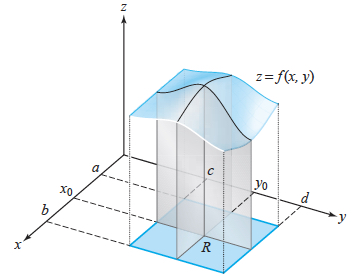

In [ ]:
print('Tomado de Marsden & Tromba  (2011)')
Image(filename='/content/drive/MyDrive/Figures/iter.jpg')

Considere la región sólida bajo la gráfica de $ z = f (x, y)$ definido en la región $[a, b] × [c, d]$, donde $f$ es continua y mayor que cero. Hay dos posibles áreas de sección transversal como se ve en la figura. La sección transversal determinada por un plano de corte en $x = x_0$, es la región plana bajo la gráfica de $z = f (x_0, y)$ de $y = c$ a $y = d$.

1.   Describa el área de la sección transversal como una integral.
2.   Use esta descripción para obtener la formulación de integral doble iterada:

$$V(x)=\int_a^b A(x)\, dx=\int_a^b\int_c^d f(x,y)\,dy dx$$



In [ ]:
#@title Ejemplos (Integral doble como volumen) { display-mode: "form" }

import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/kXwzQEKV", ##deu55wzs Cav auHB2YWq
  width="1020px",
  height="480px"
  )

IP.display_html(iframe)

##Ejemplos

1.   Sea $z=f(x,y)=x^2+y^2$ y $R=[-1,1]\times[0,1]$. Evalúe la integral $$\int\int_R f(x,y)\, dx dy$$

R/ $$\int_{-1}^1\int_0^1 x^2+y^2\, dy dx=\int_{-1}^1 \left[ x^2y+\frac{y^3}{3}\right]_0^1\, dx=\int_{-1}^1  x^2+\frac{1}{3}\, dx=\left[ \frac{x^3}{3}+\frac{1}{3}x\right]_{-1}^1=\frac{4}{3}$$
2.   Calcule $$\int\int_S \cos x\sin y\, dx dy $$ donde $S$ es el cuadrado $[0,\pi/2]\times[0,\pi/2]$.

R/ $$\int_0^{\pi/2}\int_0^{\pi/2} \cos x\sin y\, dx dy=\int_0^{\pi/2} \left[ \sin x\sin y\,\right]_0^{\pi/2}\, dy=\int_0^{\pi/2} \sin y\, dy=\left[ -\cos y\right]_0^{\pi/2}=1$$



# La integral doble sobre un rectángulo

Se recomienda la lectura de la sección 5.2 del libro de Marsden para tener un sabor de la teoría de integración, sin entrar en el rigor de las demostraciones, sino en captar las ideas geométricas sobre las cuáles se sustentan los cálculos de este tipo de integrales y sus propiedades. A continuación se enuncian algunas definiciones y resultados importantes.

**Definición (Integral Doble)** Si una sucesión ${S_n}$ de sumas de Riemann par una función $f=f(x,y)$ converge a un límite $S$ cuando $n→\infty$ y si el límite $S$ es el mismo para cualquier elección de puntos $c_{jk}$ en los subrectángulos $R_{jk}$, entonces decimos que $f$ es integrable sobre $R$ y escribimos:

$$\int\int_R f(x,y)\, dA= \int\int_R f(x,y)\, dx dy,$$

donde $$S=\lim_{n→\infty}\sum_{j,k=0}^{n-1}f(c_{jk})\,\Delta x\Delta y=\int\int_R f\, dx dy.$$

**Nota:** De la sección 5.2 usted debe hacer una lectura juiciosa de las  propiedades de la integral doble. Prestar especial atención de las figuras de dicho apartado.

**Teorema (Fubini)** Sea $f$ una función continua de dominio rectangular $R = [a, b] × [c, d]$. Entonces $$\int_a^b \int_c^d f(x,y)\, dy\, dx= \int_c^d \int_a^b f(x,y)\, dx\, dy=\int_R f(x,y) \,dA$$

#Ejemplo

1.   Sea $f(x,y)=y(x^3-12x)$ y $R=[-2,1]\times[0,1]$. Evalúe las integrales $$\int\int_R f(x,y)\, dx dy\quad \mbox{y}\int\int_R f(x,y)\, dy dx.$$

#Algunos comandos de matplotlib para dibujar funciones de dos variables

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits import mplot3d

def f(x, y):
    return x ** 2 + y ** 2#np.sin(np.sqrt(x ** 2 + y ** 2))

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

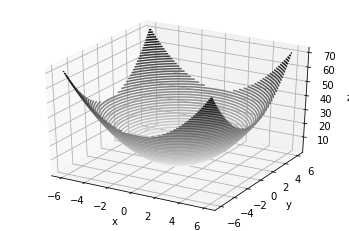

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 50, cmap='binary')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

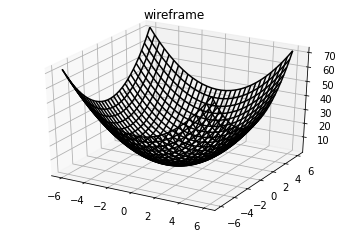

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='black')
ax.set_title('wireframe');

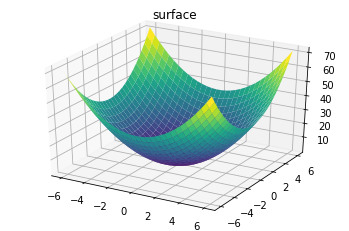

In [ ]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('surface');